In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

In [5]:
# Cargar el dataset de entrenamiento
df = pd.read_parquet("dataset_general.parquet")
df.describe()

,year_key,month_of_year,day_of_month,iso_day_of_week,tavg,prcp,wspd
count,3553073.0,3.553073e+06,3.553073e+06,3.553073e+06,3.553073e+06,3.429170e+06,3.553073e+06
mean,2024.0,6.748365e+00,1.567517e+01,3.472115e+00,1.920254e+01,2.755301e+00,8.603272e+00
std,0.0,3.554334e+00,8.765719e+00,1.765411e+00,5.488985e+00,9.352298e+00,2.829329e+00
min,2024.0,1.000000e+00,1.000000e+00,1.000000e+00,3.700000e+00,0.000000e+00,1.200000e+00
25%,2024.0,4.000000e+00,8.000000e+00,2.000000e+00,1.520000e+01,0.000000e+00,6.600000e+00
50%,2024.0,7.000000e+00,1.600000e+01,3.000000e+00,1.950000e+01,0.000000e+00,8.600000e+00
75%,2024.0,1.000000e+01,2.300000e+01,5.000000e+00,2.390000e+01,2.000000e-01,1.050000e+01
max,2024.0,1.200000e+01,3.100000e+01,7.000000e+00,3.350000e+01,9.500000e+01,2.150000e+01


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553073 entries, 0 to 3553072
Data columns (total 10 columns):
 #   Column            Dtype  
---  ------            -----  
 0   year_key          int32  
 1   month_of_year     int64  
 2   day_of_month      int64  
 3   iso_day_of_week   int64  
 4   estacion_origen   object 
 5   estacion_destino  object 
 6   grupo_edad        object 
 7   tavg              float64
 8   prcp              float64
 9   wspd              float64
dtypes: float64(3), int32(1), int64(3), object(3)
memory usage: 257.5+ MB


In [24]:
df.head(2000)

,year_key,month_of_year,day_of_month,iso_day_of_week,estacion_origen,estacion_destino,grupo_edad,tavg,prcp,wspd
0,2024,10,20,7,045 - Uruguay,045 - Uruguay,36-45,25.1,0.3,14.2
1,2024,10,20,7,293 - GREGORIO DE LAFERRERE,293 - GREGORIO DE LAFERRERE,26-35,25.1,0.3,14.2
2,2024,10,20,7,271 - VILLA SOLDATI II,271 - VILLA SOLDATI II,19-25,25.1,0.3,14.2
3,2024,10,20,7,145 - RAVIGNANI,145 - RAVIGNANI,19-25,25.1,0.3,14.2
4,2024,10,20,7,117 - HUMBERTO 1°,117 - HUMBERTO 1°,36-45,25.1,0.3,14.2
...,...,...,...,...,...,...,...,...,...,...
1995,2024,10,18,5,099 - Malabia,266 - PLAZA SABATTINI,None,21.1,0.0,8.9
1996,2024,10,18,5,015 - AMENABAR,136 - Acevedo,None,21.1,0.0,8.9
1997,2024,10,18,5,173 - EL LIBERTADOR,203 - Beiro,None,21.1,0.0,8.9
1998,2024,10,18,5,156 - Plaza Alemania,261 - QUINTEROS LIDORO,None,21.1,0.0,8.9


In [17]:
df_resumen = df.groupby(['year_key', 'month_of_year', 'day_of_month', 'tavg', 'prcp', 'wspd']).size().reset_index(name='cantidad_recorridos')
# Renombrar columnas para que coincidan con lo que espera pd.to_datetime
df_resumen['fecha'] = pd.to_datetime(df_resumen[['year_key', 'month_of_year', 'day_of_month']].rename(
	columns={'year_key': 'year', 'month_of_year': 'month', 'day_of_month': 'day'}
))
df_resumen.set_index('fecha', inplace=True)
df_resumen.drop(columns=['year_key', 'month_of_year', 'day_of_month'], inplace=True)
df_resumen.head()

,tavg,prcp,wspd,cantidad_recorridos
fecha,,,,
2024-01-01,25.2,2.2,9.5,4787
2024-01-02,24.9,0.0,9.7,10016
2024-01-03,24.2,9.9,11.6,11045
2024-01-04,25.2,0.0,11.8,10936
2024-01-05,21.2,3.0,11.4,10253


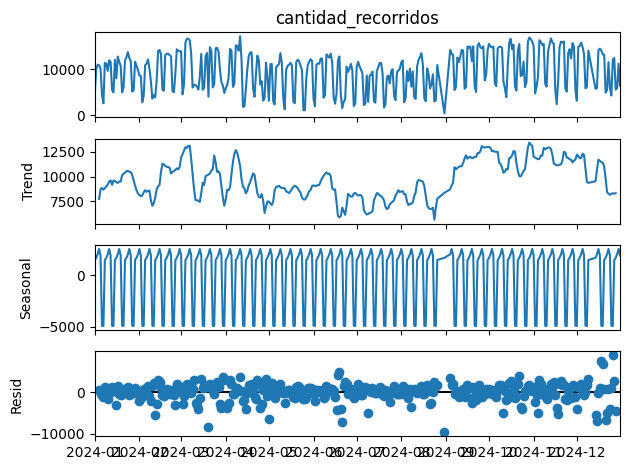

In [18]:
# Descomposición (usa 'additive' o 'multiplicative' según el comportamiento de la serie)
decomposition = seasonal_decompose(df_resumen['cantidad_recorridos'], model='additive', period=7)  # Por ejemplo: 7 si esperas estacionalidad semanal

# Plot
decomposition.plot()
plt.tight_layout()
plt.show()

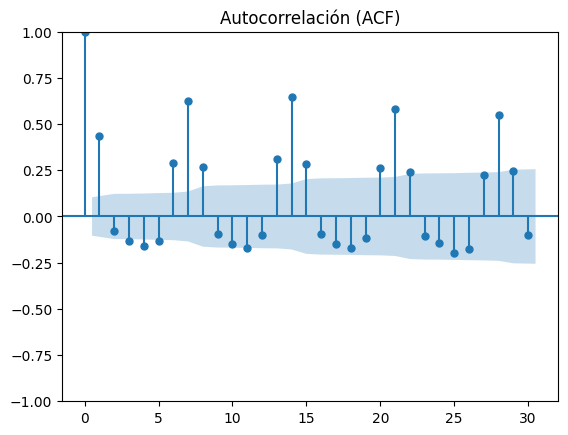

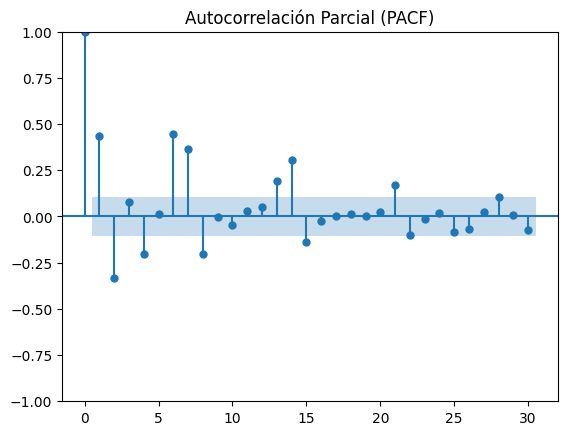

In [ ]:
# ACF muestra correlaciones con lags anteriores
plot_acf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación (ACF)')
plt.show()

# PACF muestra correlaciones parciales (importante para AR terms)
plot_pacf(df_resumen['cantidad_recorridos'], lags=30)
plt.title('Autocorrelación Parcial (PACF)')
plt.show()

In [20]:
test_result = acorr_ljungbox(df_resumen['cantidad_recorridos'], lags=[7, 14, 21], return_df=True)
print(test_result)

       lb_stat      lb_pvalue
7   266.851872   7.137217e-54
14  509.005654   1.142797e-99
21  721.231932  4.321430e-139


/Users/dreitano/projects/maestria/proyectos_maestria/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/dreitano/projects/maestria/proyectos_maestria/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


MAE: 3966.52, RMSE: 5443.72


/Users/dreitano/projects/maestria/proyectos_maestria/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/dreitano/projects/maestria/proyectos_maestria/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


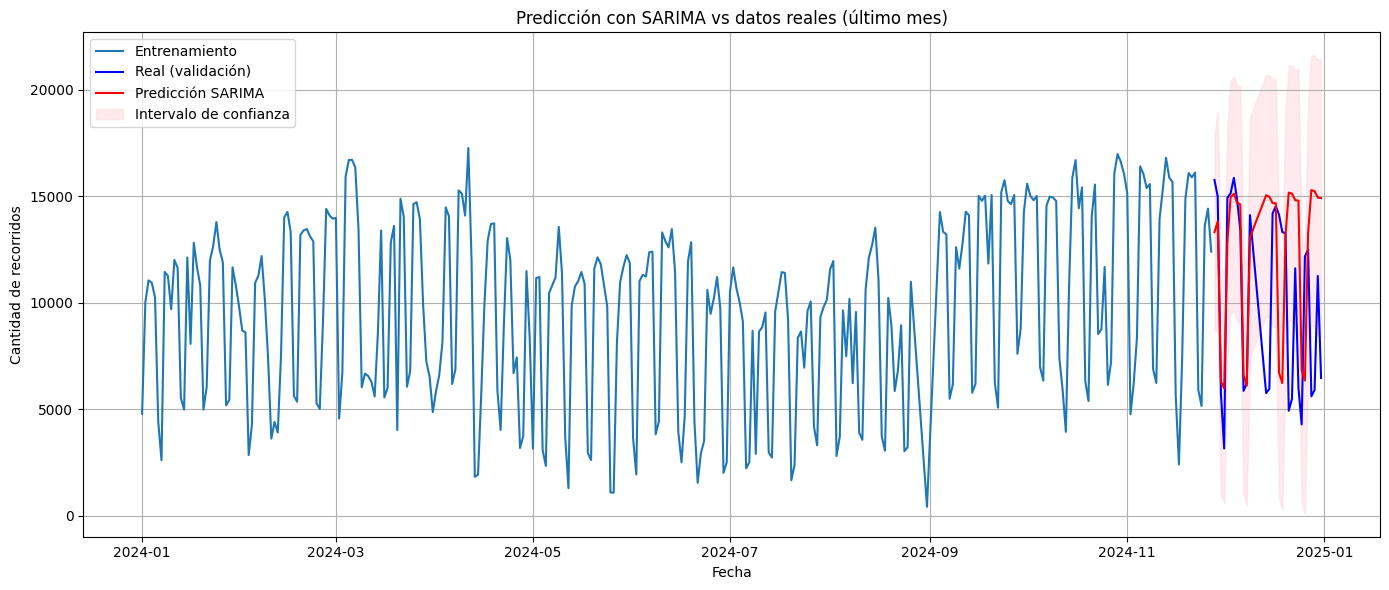

In [21]:
# Asegurar que el índice es datetime
df_resumen.index = pd.to_datetime(df_resumen.index)

# Separar el último mes (30 días) para validación
n_valid = 30
train = df_resumen.iloc[:-n_valid]
valid = df_resumen.iloc[-n_valid:]

# Entrenar modelo SARIMA con estacionalidad semanal
model = SARIMAX(train['cantidad_recorridos'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)

result = model.fit(disp=False)

# Predecir sobre el período de validación
forecast = result.get_forecast(steps=n_valid)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Evaluar el modelo
mae = mean_absolute_error(valid['cantidad_recorridos'], forecast_mean)
rmse = np.sqrt(mean_squared_error(valid['cantidad_recorridos'], forecast_mean))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar resultados
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['cantidad_recorridos'], label='Entrenamiento')
plt.plot(valid.index, valid['cantidad_recorridos'], label='Real (validación)', color='blue')
plt.plot(valid.index, forecast_mean, label='Predicción SARIMA', color='red')
plt.fill_between(valid.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Intervalo de confianza')
plt.legend()
plt.title('Predicción con SARIMA vs datos reales (último mes)')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de recorridos')
plt.grid(True)
plt.tight_layout()
plt.show()


MAE: 2081.80, RMSE: 3036.62


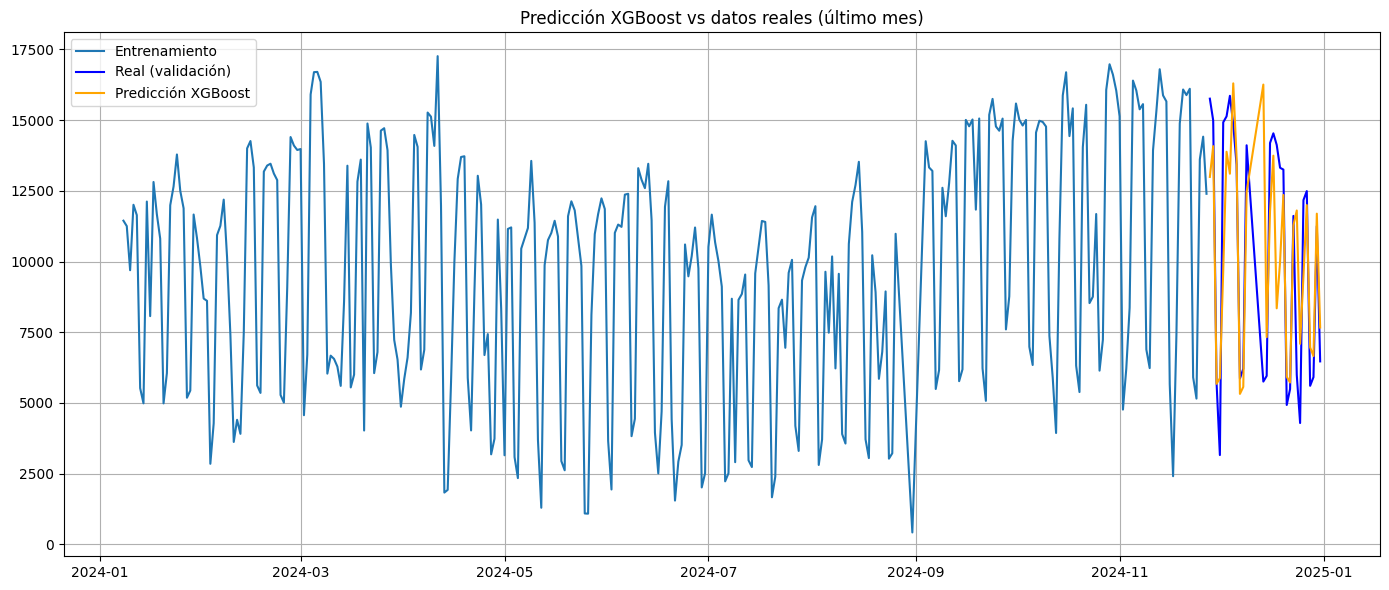

In [ ]:
# Asumimos que df_resumen tiene un índice datetime y una columna 'cantidad_recorridos'
serie = df_resumen['cantidad_recorridos'].copy()

# Crear características: lags de los últimos 7 días
def create_lag_features(series, lags=7):
    df = pd.DataFrame({'target': series})
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = series.shift(i)
    return df.dropna()

df_lags = create_lag_features(serie)

# Separar en train y valid (últimos 30 días)
n_valid = 30
train = df_lags.iloc[:-n_valid]
valid = df_lags.iloc[-n_valid:]

X_train = train.drop(columns='target')
y_train = train['target']
X_valid = valid.drop(columns='target')
y_valid = valid['target']

# Entrenar XGBoost
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Predecir y evaluar
y_pred = model.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(y_train.index, y_train, label='Entrenamiento')
plt.plot(y_valid.index, y_valid, label='Real (validación)', color='blue')
plt.plot(y_valid.index, y_pred, label='Predicción XGBoost', color='orange')
plt.legend()
plt.title('Predicción XGBoost vs datos reales (último mes)')
plt.grid(True)
plt.tight_layout()
plt.show()